In [2]:
#created on 27-4-2026
#new Dataset

#update output folders if required
#update output variables in mass weighted random sampling (eg. m_rsg versus m_sg)
#update weight in weighted R2 score (eg: r+s+g vs s+g)
#update HC and y (output variable) accordingly
#update corr with respect to the output variable in HC 
#update feature names accordingly

output_folder_name = '27-4-2026_renamed_feature_names_ql_by_(ql+qi)_using_all_locals_with_HC'
HC_output_file_name = 'HC_ql_by_(ql+qi)_using_all_locals.csv' #write .csv
Dendrogram_output_file_name = 'Dendrogram_ql_by_(ql+qi)_using_all_locals.png' #write .png
output_fraction = r"$\mathbf{\frac{q_l}{q_l + q_i}}$"
pred_vs_actual_output_file_name = 'pred_vs_actual_ql_by_(ql+qi)_using_all_locals.png' #write .png


import time
overall_start_time = time.time()
import os
import importlib
import sys

# #Remove cached modules
# for module_name in list(sys.modules.keys()):
#     if 'dataset_init' in module_name:
#         del sys.modules[module_name]

# #Reimport
# from Tools import dataset_init

#To go up one level from 'Codes' sub-folder to 'MS' Folder, then the other sub-folders such as 'File_management' are accessible
MS_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(MS_PATH)

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
# from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

#################################################################
# Log.init_log(os.path.join('../output'), filename=f"Log_ML.txt")
Log.init_log(os.path.join(MS_PATH, 'output'), filename="Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

# options_json=JFE.get_json_data("options.json")
options_json = JFE.get_json_data(os.path.join(MS_PATH, "options.json"))

options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
# ds = dataset_init.ds_init_3d(myJob, chunks={}) 
ds = dataset_init.ds_init(myJob, chunks={}) 

The job folder path : /home/m/m301214/MS/output/Log_ML.txt
2026 Jul 31 17:35:42 > Log nicely initialized 
2026 Jul 31 17:35:42 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2026 Jul 31 17:35:42 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003
2026 Jul 31 17:35:42 > (DI0021) Found 35 time-varying files in date range
2026 Jul 31 17:35:42 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim/build/experiments/pod0003/pod0003_atm_vgrid_ml.nc
2026 Jul 31 17:35:42 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2026 Jul 31 17:35:42 > (DI0024) Dimensions in vgrid: {'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60}
2026 Jul 31 17:35:42 > (DI0037) Loading horizontal grid data from /

In [3]:
ds

<xarray.Dataset> Size: 78GB
Dimensions:    (ncells: 20971520, time: 1, height: 61, height_2: 61)
Coordinates:
    clon       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    clat       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
  * time       (time) datetime64[ns] 8B 2020-01-12
  * height     (height) float64 488B 2.0 31.0 32.0 33.0 ... 87.0 88.0 89.0 90.0
  * height_2   (height_2) float64 488B 10.0 31.0 32.0 33.0 ... 88.0 89.0 90.0
Dimensions without coordinates: ncells
Data variables: (12/22)
    cell_area  (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    pr         (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    tas        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    clivi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    cllvi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    qgvi       (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ...         ...
    rho        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    dzghalf    (height, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    zg         (height_2, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ua         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    va         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    pfull      (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
Attributes: (12/46)
    CDI:                      Climate Data Interface version 2.5.2.1 (https:/...
    Conventions:              CF-1.6
    number_of_grid_used:      55
    grid_file_uri:            http://icon-downloads.mpimet.mpg.de/grids/publi...
    uuidOfHGrid:              9a8d03ba-2027-11ef-a2ba-c74e1b4d7fe9
    institution:              Max Planck Institute for Meteorology/Deutscher ...
    ...                       ...
    topography:               modified SRTM30
    symmetry:                 along equator
    subcentre:                0
    ICON_grid_file_uri:       http://icon-downloads.mpimet.mpg.de/grids/publi...
    optimization:             spring dynamics
    NCO:                      netCDF Operators version 5.0.6 (Homepage = http...

In [6]:
#The following will apply to all plots from this cell onwards
#To make the plots better for publication

plt.rcParams.update({
    'font.size': 12,          # base font size
    'axes.labelsize': 13,     # x/y axis labels
    'axes.titlesize': 13,     # title
    'xtick.labelsize': 11,    # tick labels
    'ytick.labelsize': 11,
    'font.family': 'serif',   # matches most journal fonts (Times-style)
})

In [4]:
#Functions

#RH from SH
def RH_from_SH(pfull, hus, ta, T_0= 273.16):
    RH = 0.26 * pfull * hus / np.exp(17.67 * (ta - T_0) / (ta - 29.65))
    return RH

#Weighted R2 score
def weighted_r_squared(y_true, y_pred, weight):
    mean_y_true = np.mean(y_true)
    ss_total = np.sum( weight * (y_true - mean_y_true)**2)
    ss_residual = np.sum( weight * (y_true - y_pred)**2)
    r2_score = 1 - (ss_residual / ss_total)
    return r2_score


In [8]:
#Data Pre-processing

#subset of the original dataset

seed = 1
sample_frac = 0.001

ht=31
data=ds.sel(height=ht, height_2=ht) 

total = data['clw'] + data['cli']
data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = data['qr'] + data['qs']+ data['qg']
data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

df = data.to_dataframe() #.sample(frac=1, random_state=seed) #frac=sample_frac

# df = data.to_dataframe().sample(frac=sample_frac, random_state=seed)

dfs = [df]  
# for ht in range(32, 91, 5): #(32, 91, 5)
for ht in range(36, 91, 5): #(32, 91, 5)
    data = ds.sel(height=ht, height_2=ht)

    total = data['clw'] + data['cli']
    data['clw/(clw+cli)'] = data['clw'].where(total != 0, 0) / total.where(total != 0, 1)
    data['cli/(clw+cli)'] = data['cli'].where(total != 0, 0) / total.where(total != 0, 1)

    total_precipitates = data['qr'] + data['qs']+ data['qg']
    data['qr/(qr+qs+qg)'] = data['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qs/(qr+qs+qg)'] = data['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
    data['qg/(qr+qs+qg)'] = data['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

    df_sampled=data.to_dataframe() #.sample(frac=1, random_state= seed+ht) #frac=sample_frac
    dfs.append(df_sampled) 
    print(f"Last value of clon in df with height {ht} is", df_sampled['clon'].iloc[-1])

df = pd.concat(dfs, ignore_index=True)


prod= len(dfs[0]) * len(dfs)
print("Expected length of df: ", prod)
print('Final length of df: ', len(df))

#threshold

threshold = 5e-12
df_new = df[(df['cli'] + df['clw'] + df['qr'] + df['qg'] + df['qs']) >= threshold]

if df_new.empty:
    df_new = df

df = df_new


#RH data

df['RH']=RH_from_SH(df['pfull'], df['hus'], df['ta'])

count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("out-of-range count = ", count)
print("out-of-range count percent = ", 100*count/len(df['RH']), " %")

df['RH']= df['RH'].clip(lower=0, upper=100)

#Insert variables to the df
col=df.pop('RH')
df.insert(16, 'RH', col) #hus is at 15th position
#df.pop('hus')

df['clw+cli']=df['clw']+df['cli']
col=df.pop('clw+cli')
df.insert(26, 'clw+cli', col) 

#Include 'cloud liquid water path + cloud ice path' as a feature.
df['cllvi+clivi']=df['cllvi']+df['clivi']
col=df.pop('cllvi+clivi')
df.insert(27, 'cllvi+clivi', col) 

# df['m_ci']=df['dzghalf']*df['rho']*df['cell_area']* (df['clw']+df['cli'])

# col=df.pop('m_ci')
# df.insert(28, 'm_ci', col) 

#mass-weighted random sampling

df['m_li']=df['dzghalf']*df['rho']*df['cell_area']* (df['clw']+df['cli']) #update as required

col=df.pop('m_li')
df.insert(28, 'm_li', col) 

df = df.sort_values(by='m_li', ascending=False)
df = df.reset_index(drop=True)

total_mass = df['m_li'].sum()

df['cum_mass'] = df['m_li'].cumsum()

col=df.pop('cum_mass')
df.insert(29, 'cum_mass', col) 

#Adding another column; qr+qg+qs and use it later as an input feature

df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']

col=df.pop('qr+qg+qs')
df.insert(30, 'qr+qg+qs', col)

#mass-weighted random sampling (continued)
n_samples= int(np.floor(len(df) * 0.1)) #we are taking a way smaller dataset because of this 
# n_samples= int(np.floor(len(df))) 
np.random.seed(29)

random_values = np.random.uniform(0, total_mass, size=n_samples)

print('Random values: ', random_values)

indices= np.searchsorted(df['cum_mass'].values, random_values)

df_orig=df

df = df.iloc[indices].reset_index(drop=True)

#OBtain lon and lat from clon and clat respectively
df['lon'] = df['clon']*180/np.pi #in degrees
df['lat'] = df['clat']*180/np.pi #in degrees


Last value of clon in df with height 36 is 1.3343108942333097
Last value of clon in df with height 41 is 1.3343108942333097
Last value of clon in df with height 46 is 1.3343108942333097
Last value of clon in df with height 51 is 1.3343108942333097
Last value of clon in df with height 56 is 1.3343108942333097
Last value of clon in df with height 61 is 1.3343108942333097
Last value of clon in df with height 66 is 1.3343108942333097
Last value of clon in df with height 71 is 1.3343108942333097
Last value of clon in df with height 76 is 1.3343108942333097
Last value of clon in df with height 81 is 1.3343108942333097
Last value of clon in df with height 86 is 1.3343108942333097
Expected length of df:  251658240
Final length of df:  251658240
out-of-range count =  571480
out-of-range count percent =  0.9012190553676325  %
Random values:  [7.44464208e+12 2.45556980e+12 6.31387884e+11 ... 8.55802206e+12
 6.80526798e+12 5.02578609e+12]


In [9]:
df['qg/(qs+qg)'] = df['qg'] / (df['qs']+ df['qg']) 
print('Number of NaN values in qg/(qs+qg) column: ', df['qg/(qs+qg)'].isna().sum())
df = df.dropna(subset=['qg/(qs+qg)'])
print('Number of NaN values in qg/(qs+qg) column now: ', df['qg/(qs+qg)'].isna().sum())

Number of NaN values in qg/(qs+qg) column:  326


Number of NaN values in qg/(qs+qg) column now:  0


In [10]:
df.columns

Index(['clon', 'clat', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'ta', 'wa',
       'rho', 'dzghalf', 'zg', 'ua', 'va', 'pfull', 'height', 'clw+cli',
       'cllvi+clivi', 'm_li', 'cum_mass', 'qr+qg+qs', 'height_2',
       'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)', 'qs/(qr+qs+qg)',
       'qg/(qr+qs+qg)', 'lon', 'lat', 'qg/(qs+qg)'],
      dtype='str')

Hierarchical Clustering

Shape of transposed DataFrame: (13, 6340862)
Shape of linkage matrix: (12, 4)
First 10 rows of linkage DataFrame:
    c1  c2  distance  size
0   8   9  0.010901     2
1   3  12  0.080725     2
2   4  14  0.145111     3
3   5  11  0.225208     2
4  13  15  0.238113     5
5   2  10  0.489630     2
6   0   7  0.687972     2
7  17  18  0.767425     7
8   1  16  0.952205     3
9   6  19  1.080440     3


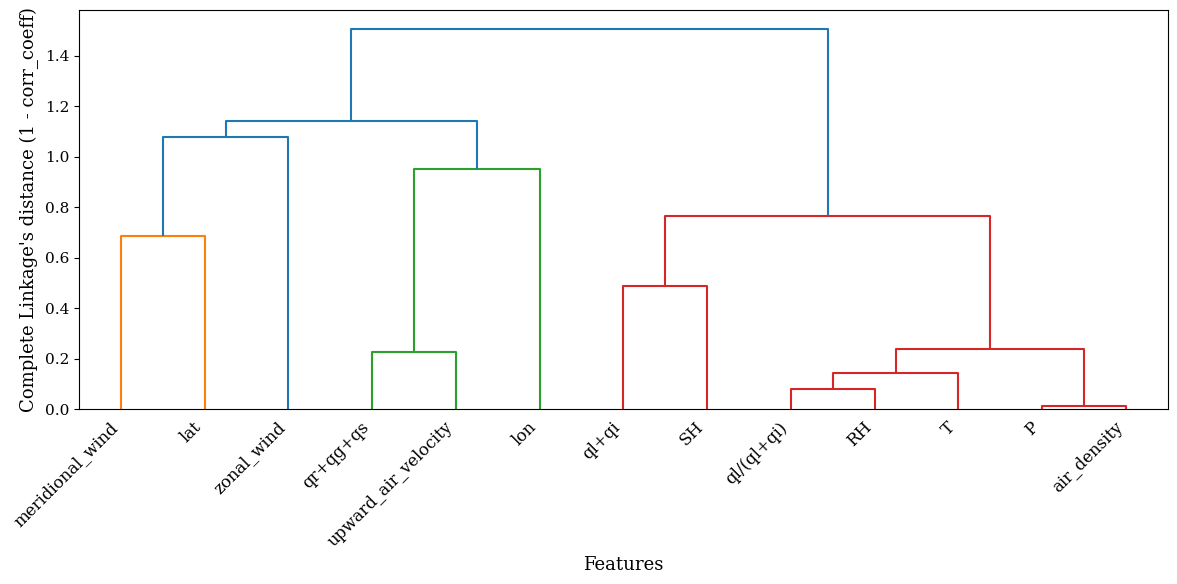

In [11]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler

# df_orig=df.copy()
#Select ft's
feature_names= ['lat','lon','hus' ,'RH','ta','wa','ua','va','rho','pfull','clw+cli','qr+qg+qs','clw/(clw+cli)'] # [lat, lon, RH,ta,wa,ua,va,pfull,clw+cli,qr+qg+qs]
# feature_names= ['lat','lon','hus' ,'RH','ta','wa','ua','va','rho','pfull','clw+cli','qr+qg+qs'] # [lat, lon, RH,ta,wa,ua,va,pfull,clw+cli,qr+qg+qs]
# feature_names= ['lat','lon','hus' ,'RH','ta','wa','ua','va','rho','pfull','clw+cli','qr+qg+qs'] # [lat, lon, RH,ta,wa,ua,va,pfull,clw+cli,qr+qg+qs]
df_features = df[feature_names]

#Standardize ft's
scaler= StandardScaler()
df_scaled= scaler.fit_transform(df_features)
df_scaled= pd.DataFrame(df_scaled, columns=df_features.columns)

#Transpose so ft's are in rows
df_transposed = df_scaled.transpose()
print("Shape of transposed DataFrame:", np.shape(df_transposed))

# linked=linkage(df_transposed, method='complete', metric='euclidean')
linked=linkage(df_transposed, method='complete', metric='correlation')
print("Shape of linkage matrix:", np.shape(linked))

df_linked= pd.DataFrame(linked, columns=['c1','c2','distance','size'])
df_linked[['c1','c2','size']]= df_linked[['c1','c2','size']].astype('int')
print("First 10 rows of linkage DataFrame:\n", df_linked.head(10))

#Rename variables in the plot for better understanding
rename_map = {
    'hus':          'SH',
    'ta':           'T',
    'wa':           'upward_air_velocity',
    'ua':           'zonal_wind',
    'va':           'meridional_wind',
    'rho':          'air_density',
    'pfull':        'P',
    'clw':          'ql',
    'cli':          'qi',
    'clw+cli':      'ql+qi',
    'cllvi':        'CLWP',
    'clivi':        'CIP',
    'cllvi+clivi':   'CLWP+CIP',
    'clw/(clw+cli)':   'ql/(ql+qi)'
}

display_labels = [rename_map.get(f, f) for f in df_transposed.index]

#Create the Dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked,
            orientation='top',
              labels=display_labels,
                distance_sort='descending',
                  show_leaf_counts=True)

plt.xlabel('Features')
# plt.ylabel('Complete Linkage\'s distance (Euclidean)')
plt.ylabel('Complete Linkage\'s distance (1 - corr_coeff)')

plt.xticks(rotation=45, ha='right')   #tilt labels
plt.tight_layout()                    #adjust spacing automatically

Dendrogram_output_path = os.path.join('../output', output_folder_name, Dendrogram_output_file_name)
plt.savefig(Dendrogram_output_path,  bbox_inches='tight') #bbox_inches='tight' so that labels don't get cut off

plt.show()

In [12]:
#Now, let's set a limit on the number of clusters
num_clusters=3

labels= fcluster(linked, t=num_clusters, criterion='maxclust')
print("Cluster labels for each feature:", labels)

correlations=[]
for col in df_features.columns:
    corr=df['clw/(clw+cli)'].corr(df[col]) #update it as required
    corr=round(corr,3)
    correlations.append(corr)

df_clusters= pd.DataFrame(list(zip(df_features.columns, labels, correlations)),
                          columns=['feature', 'cluster', 'corr'])

df_clusters['abs_corr']= df_clusters['corr'].abs()

df_clusters.sort_values(by=['cluster','abs_corr'], ascending=[True, False], inplace=True) #inplace=True changes this very df itself
df_clusters.reset_index(drop=True, inplace=True) #drop=True prevents the old indices from being added as a column
print("DataFrame of clustered features:\n", df_clusters)

HC_output_path = os.path.join('../output', output_folder_name, HC_output_file_name)
df_clusters.to_csv(HC_output_path, index=False)


Cluster labels for each feature: [3 2 1 1 1 2 3 3 1 1 1 2 1]


DataFrame of clustered features:
           feature  cluster   corr  abs_corr
0   clw/(clw+cli)        1  1.000     1.000
1              RH        1  0.919     0.919
2              ta        1  0.855     0.855
3           pfull        1  0.803     0.803
4             rho        1  0.762     0.762
5             hus        1  0.593     0.593
6         clw+cli        1  0.463     0.463
7              wa        2  0.061     0.061
8             lon        2 -0.041     0.041
9        qr+qg+qs        2  0.019     0.019
10             ua        3 -0.308     0.308
11            lat        3 -0.108     0.108
12             va        3 -0.051     0.051


Number of features in cluster 1: 7
Number of features in cluster 2: 3
Number of features in cluster 3: 3


Text(0.5, 1.0, 'Cluster 2 and 3')

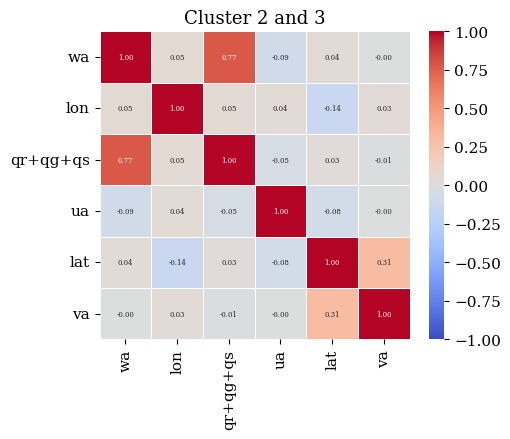

In [13]:
c1_features= df_clusters[df_clusters['cluster']==1]['feature'].tolist()
c2_features= df_clusters[df_clusters['cluster']==2]['feature'].tolist()
c3_features= df_clusters[df_clusters['cluster']==3]['feature'].tolist()

print("Number of features in cluster 1:", len(c1_features))
print("Number of features in cluster 2:", len(c2_features))
print("Number of features in cluster 3:", len(c3_features))

#Plot correlns of ft's in clusters 2 and 3
corr = df_features[np.append(c2_features, c3_features)].corr()

#plot correln. matrix
plt.figure(figsize=(5,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            fmt=".2f",
            annot_kws={"size":5},
            vmin=-1, vmax=1)

plt.title('Cluster 2 and 3')

Text(0.5, 1.0, 'Cluster 1 and 2')

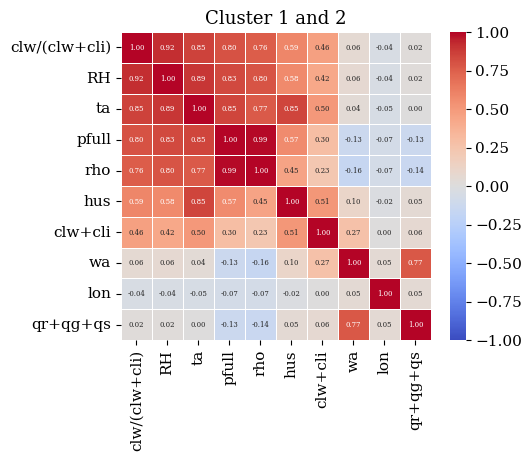

In [14]:
#Plot correlns of ft's in clusters 1 and 2
corr = df_features[np.append(c1_features, c2_features)].corr()

#plot correln. matrix
plt.figure(figsize=(5,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            fmt=".2f",
            annot_kws={"size":5},
            vmin=-1, vmax=1)

plt.title('Cluster 1 and 2')

Text(0.5, 1.0, 'Cluster 1 and 3')

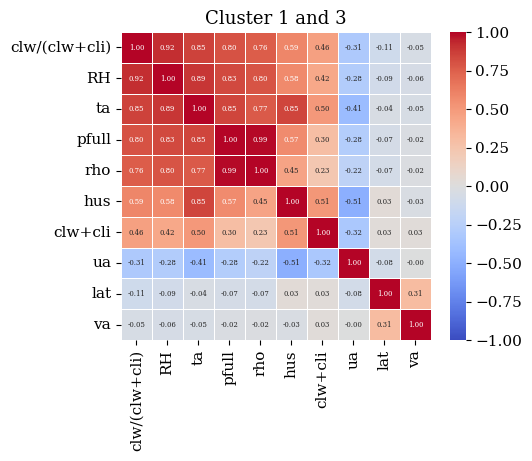

In [15]:
#Plot correlns of ft's in clusters 1 and 3
corr = df_features[np.append(c1_features, c3_features)].corr()

#plot correln. matrix
plt.figure(figsize=(5,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            fmt=".2f",
            annot_kws={"size":5},
            vmin=-1, vmax=1)

plt.title('Cluster 1 and 3')

In [16]:
feature_names= [feature for feature in feature_names if feature not in ( 'hus', 'rho', 'clw/(clw+cli)')] #update it as required

In [17]:
print(feature_names)

['lat', 'lon', 'RH', 'ta', 'wa', 'ua', 'va', 'pfull', 'clw+cli', 'qr+qg+qs']


In [18]:

X = df[feature_names] #X is a df 
y = df['clw/(clw+cli)'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

#Train using xgb
#The following 'best' parameter values have been approximated from the values otained from the previous runs to find the best parameters in different datasets

# best_parameters= grid_search.best_params_
best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

#XGBoost
# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")


Training- Elapsed time: 0.3274 minutes


In [ ]:
import joblib
joblib.dump(model, os.path.join('../output', output_folder_name, 'xgb_model_ql_by_(ql+qi)_using_all_locals'))
mj=joblib.load(os.path.join('../output', output_folder_name, 'xgb_model_ql_by_(ql+qi)_using_all_locals'))

In [23]:
#Prediction

prediction_start_time = time.time()
y_pred = mj.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max value of the fraction: ", np.max(y_pred))
print("min value of the fraction: ", np.min(y_pred))

count=0
for i in y_pred:
    if i>1 or i<0:
        # print(i)
        count+=1
print("Out-of-range count = ", count)
print("Out-of-range count percent = ", 100*count/len(y_pred) , " %")

y_pred = np.clip(y_pred, 0, 1)
# y_test=y_test.ravel()
# y_pred=y_pred.ravel()

#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

#weighted_R2_test
df_test= df.loc[X_test.index]
weight = df_test['cell_area']*df_test['dzghalf']*df_test['rho']*( df_test['clw'] + df_test['cli'] ) 

weighted_r2 = weighted_r_squared(y_test, y_pred, weight)
print("Weighted R² score: ", weighted_r2)

Prediction- Elapsed time: 0.0022 minutes
max value of the fraction:  1.2086169
min value of the fraction:  -0.124492526
Out-of-range count =  499575
Out-of-range count percent =  39.39328467015147  %
MSE_Test:  0.00026063298
RMSE_TEST: 0.016144132241606712
mae_TEST: 0.0013337479904294014
R² score:  0.9978587031364441
Weighted R² score:  0.9993931472962189


RH: 98.5303 %
ta: 0.9469 %
clw+cli: 0.3148 %
qr+qg+qs: 0.0680 %
pfull: 0.0383 %
wa: 0.0375 %
lat: 0.0182 %
va: 0.0165 %
lon: 0.0160 %
ua: 0.0136 %


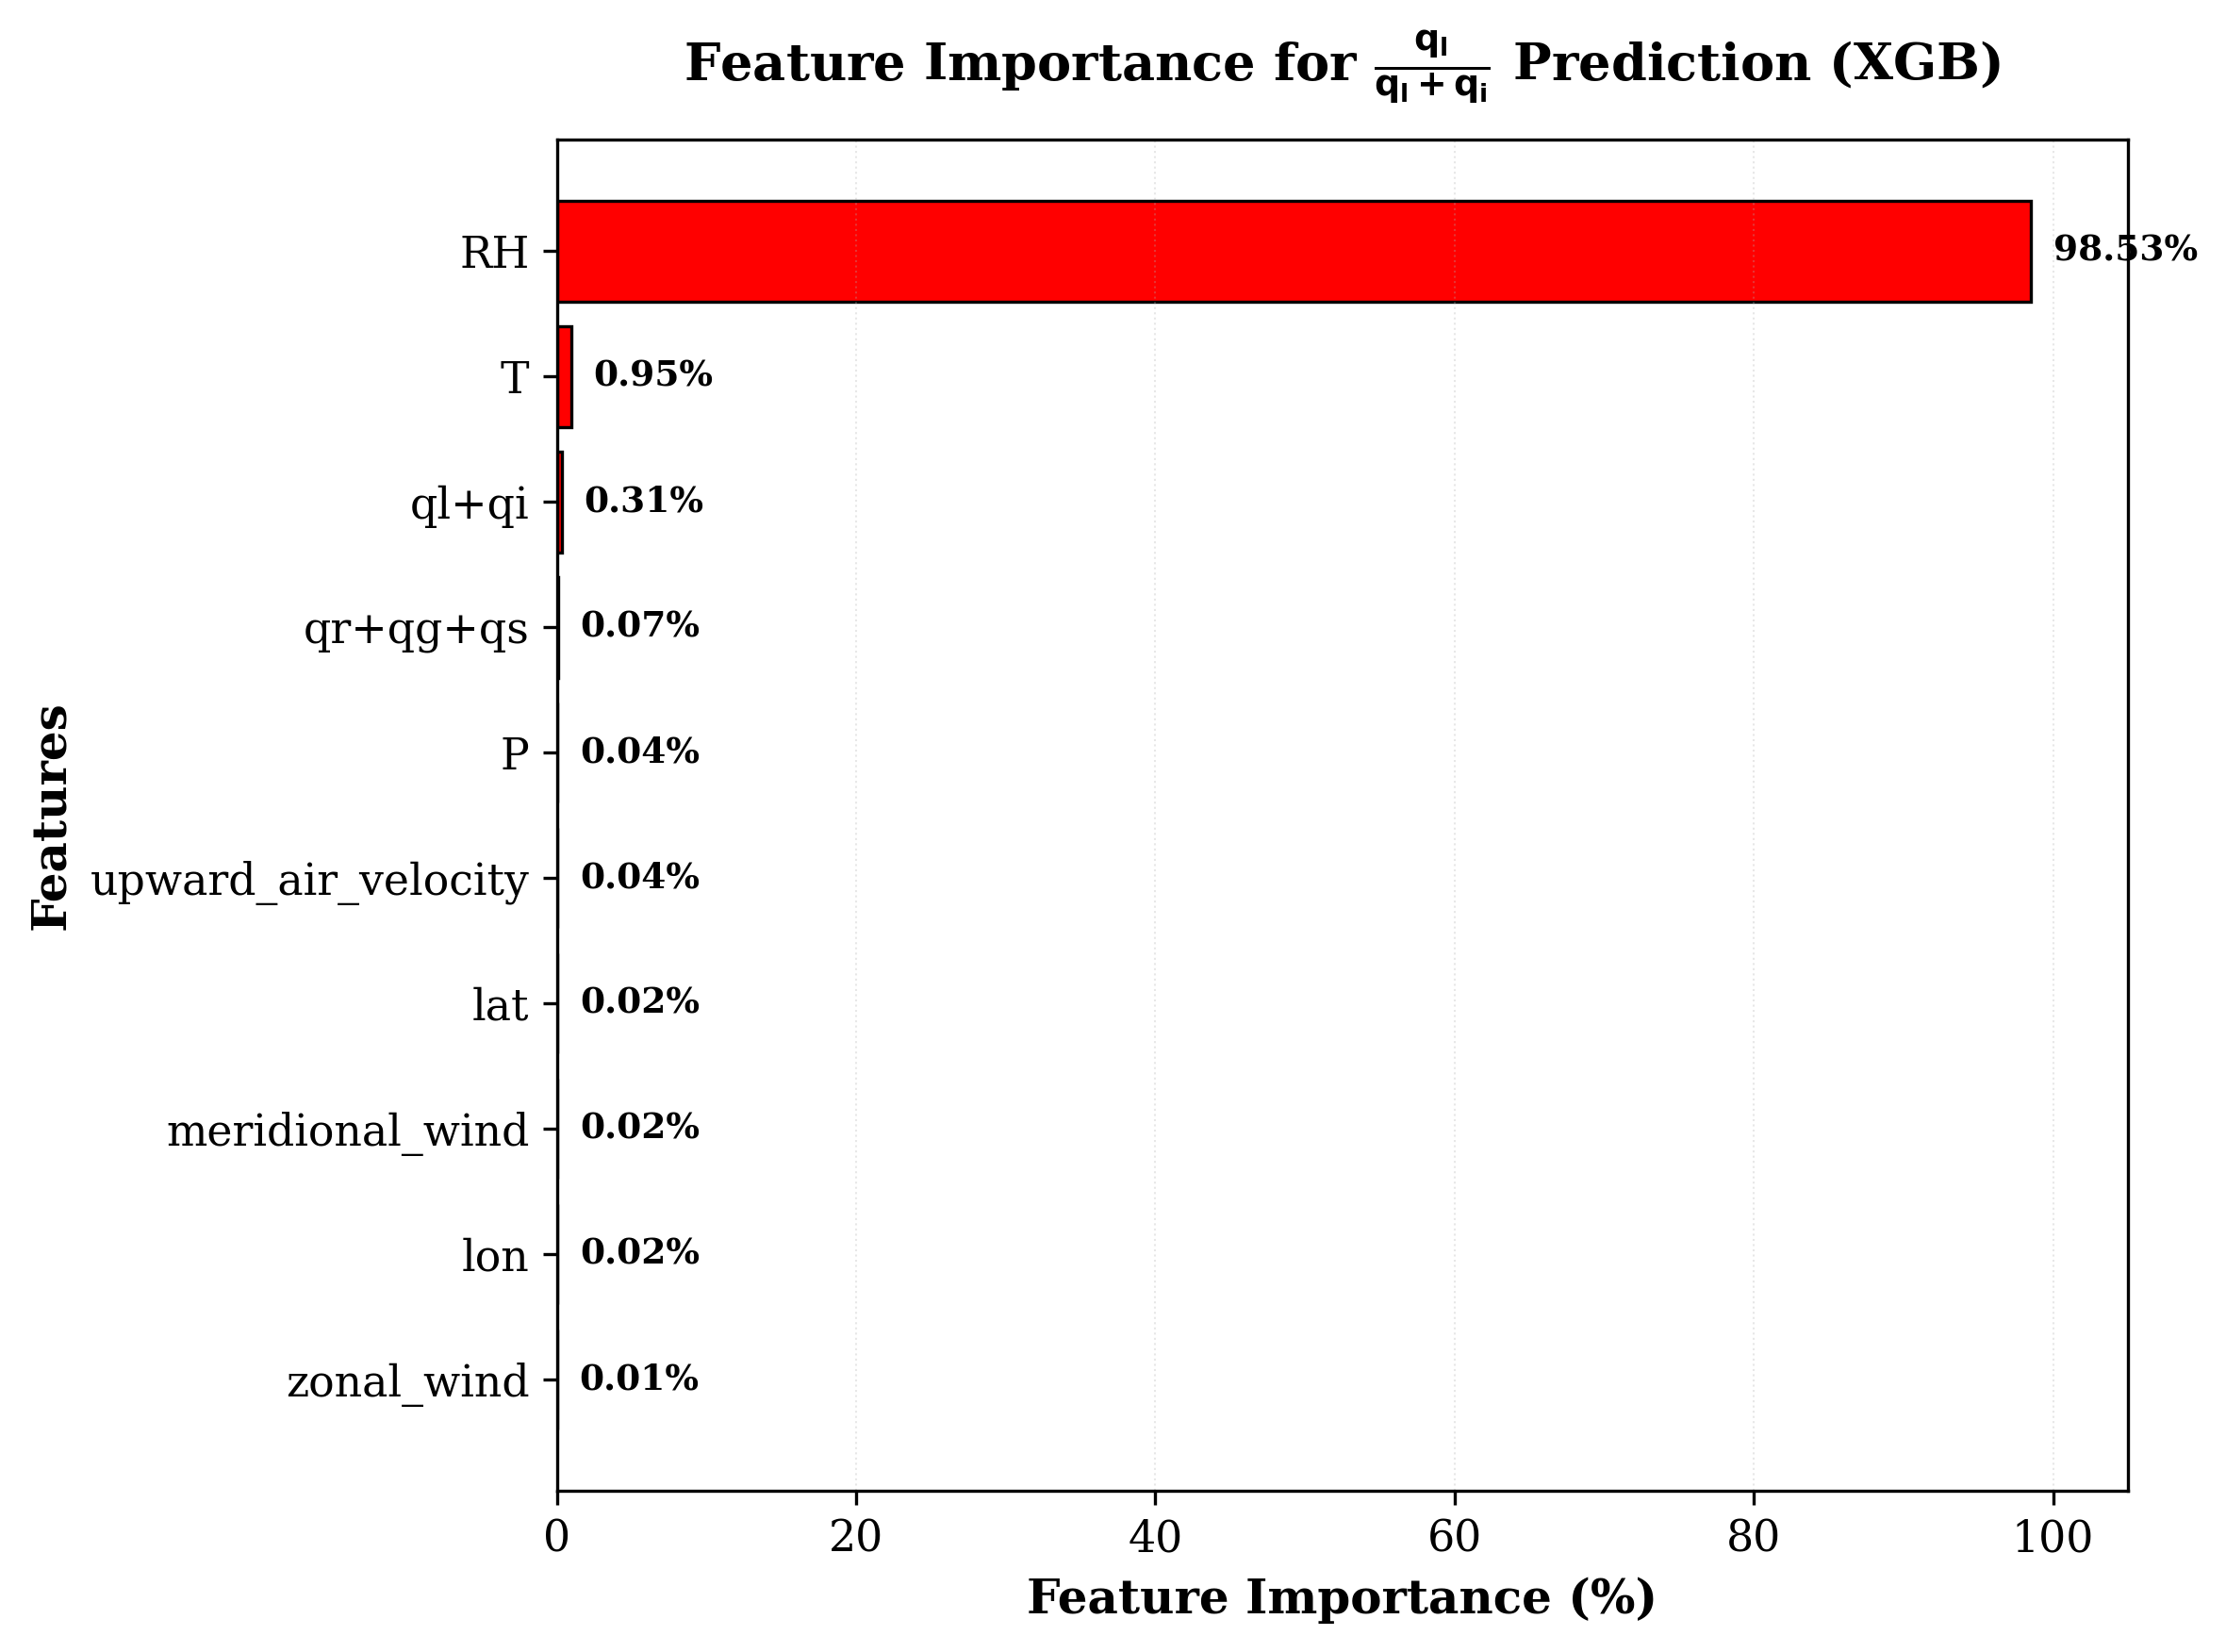

In [24]:
#Feature importance plot
importance = model.feature_importances_

#Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

#Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

#Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    # names.append(name)
    names.append(rename_map.get(name, name))
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

bars = ax.barh(names, importances, color='red', edgecolor='black', linewidth=0.8)


ax.set_xlabel("Feature Importance (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')
#ax.set_title(r"XGBoost Feature Importance: Ice-Phase Hydrometeor Fraction $\mathbf{\left(\frac{q_g}{q_s + q_g}\right)}$", 
ax.set_title(f"Feature Importance for {output_fraction} Prediction (XGB)", 
            fontsize=13, fontweight='bold', pad=15)

ax.invert_yaxis() #Highest importance at the top

#Add percentage values on bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + 1.5,
        y,
        f"{width:.2f}%",
        va="center",
        fontsize=9,
        fontweight='bold'
    )
ax.set_xlim(0, 105)

ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)

plt.savefig(f"../output/{output_folder_name}/FeatureImportance.png",
    dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


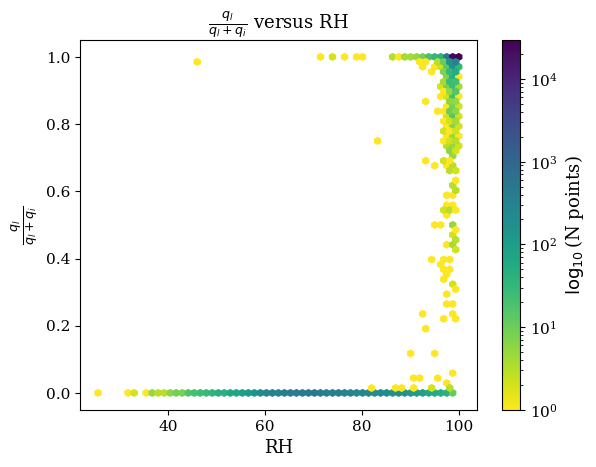

In [ ]:
plt.hexbin(
    df['RH'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    
    cmap='viridis_r', 
    bins='log'      
)
plt.colorbar(label=r"$\log_{10}$(N points)")
# plt.xlim(95, 100)
plt.xlabel("RH")
plt.ylabel(r"$\frac{q_l}{q_l + q_i}$", fontsize=13)
plt.title(r"$\frac{q_l}{q_l + q_i}$ versus RH", fontsize=13)

plt.savefig(f"../output/{output_folder_name}/ql_by_(ql+qi)_vs_RH.png",
    dpi=300, bbox_inches='tight')

plt.show()


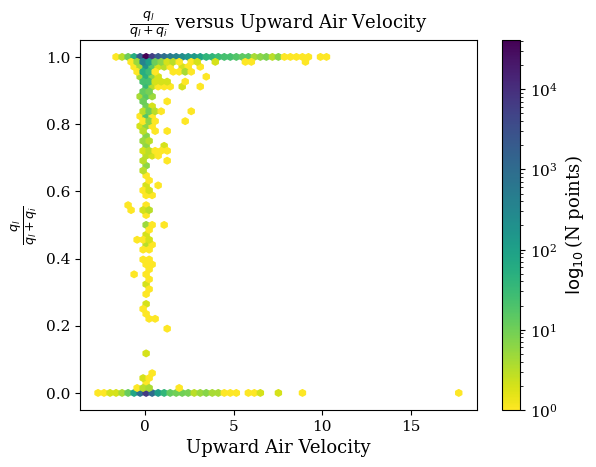

In [ ]:
plt.hexbin(
    df['wa'][::100],
    df['clw/(clw+cli)'][::100],
    gridsize=60,    
    cmap='viridis_r', 
    bins='log'      
)
plt.colorbar(label=r"$\log_{10}$(N points)")
# plt.xlim(95, 100)
plt.xlabel("Upward Air Velocity", fontsize=13)
plt.ylabel(r"$\frac{q_l}{q_l + q_i}$", fontsize=13)
plt.title(r"$\frac{q_l}{q_l + q_i}$ versus Upward Air Velocity", fontsize=13)

plt.savefig(f"../output/{output_folder_name}/ql_by_(ql+qi)_vs_upward_air_velocity.png",
    dpi=300, bbox_inches='tight')

plt.show()


Prediction- Elapsed time: 0.0007 minutes
max value of the fraction:  1.2086169
min value of the fraction:  -0.124492526


Out-of-range count =  499575
Out-of-range count percent =  39.39328467015147  %
MSE_Test:  0.00026063298
RMSE_TEST: 0.016144132241606712
mae_TEST: 0.0013337479904294014
R² score:  0.9978587031364441
Weighted R² score:  0.9993931472962189


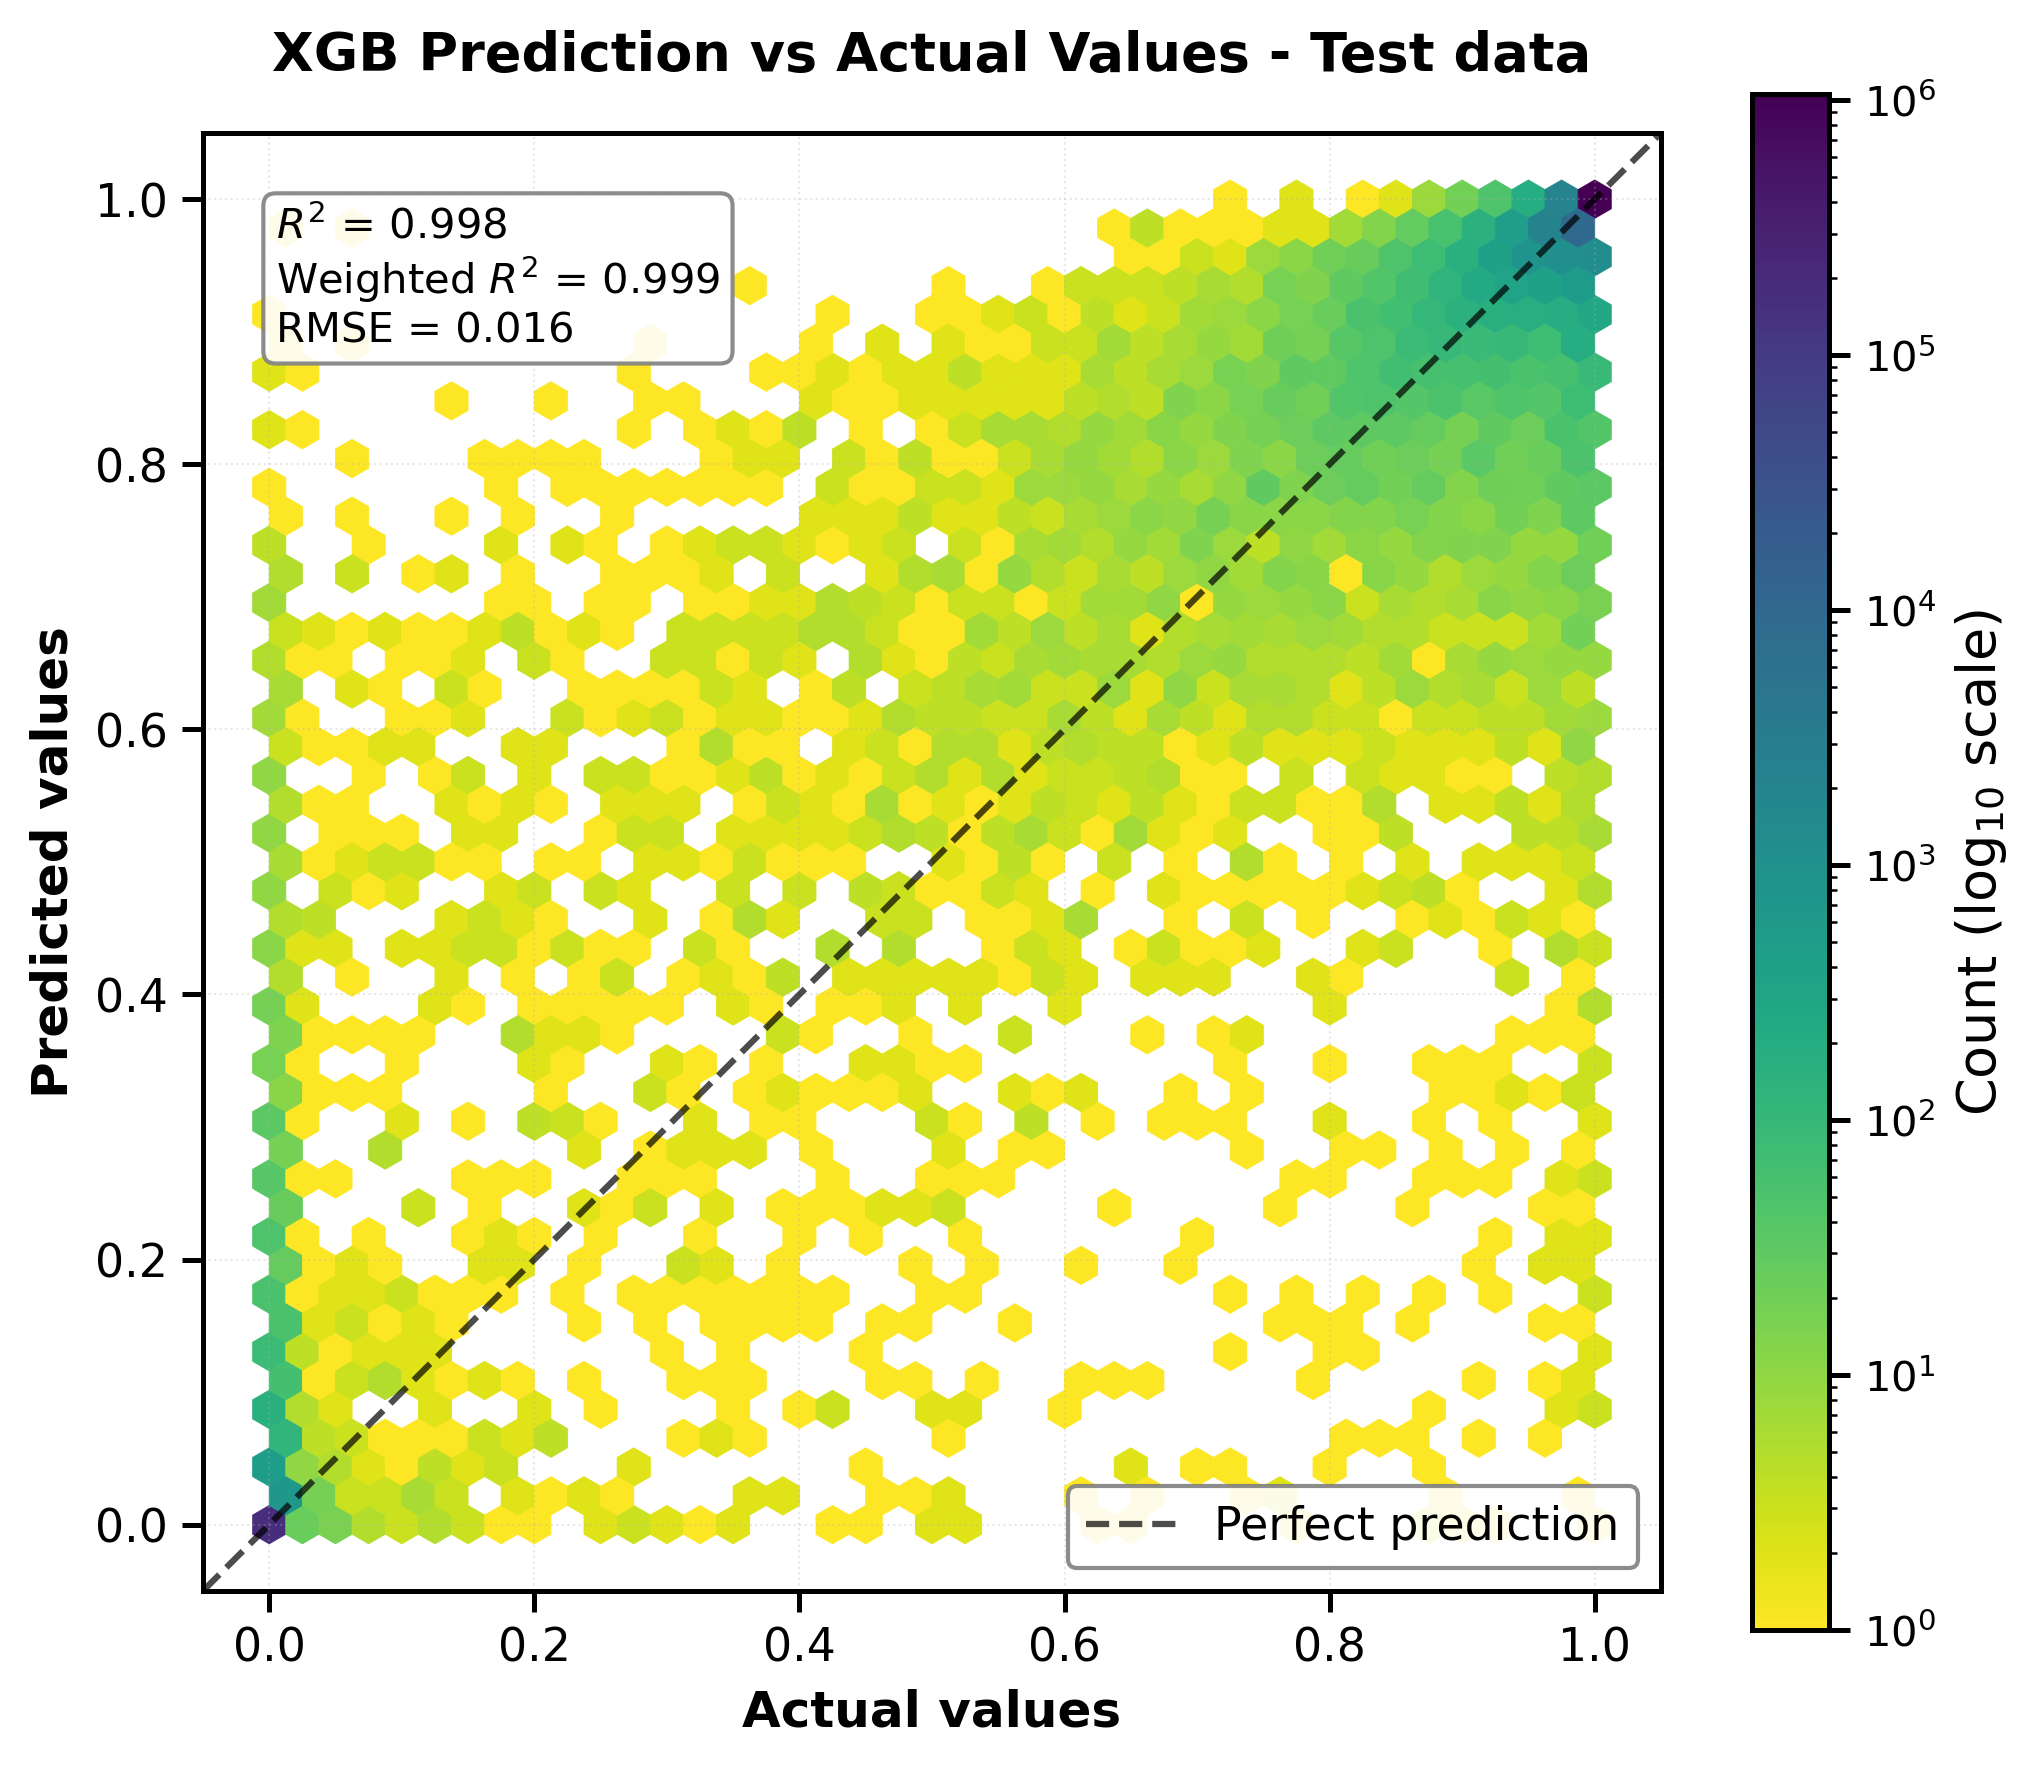

In [25]:
#Prediction

prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max value of the fraction: ", np.max(y_pred))
print("min value of the fraction: ", np.min(y_pred))

count=0
for i in y_pred:
    if i>1 or i<0:
        # print(i)
        count+=1
print("Out-of-range count = ", count)
print("Out-of-range count percent = ", 100*count/len(y_pred) , " %")

y_pred = np.clip(y_pred, 0, 1)
# y_test=y_test.ravel()
# y_pred=y_pred.ravel()

#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

#weighted_R2_test
df_test= df.loc[X_test.index]
weight = df_test['cell_area']*df_test['dzghalf']*df_test['rho']*( df_test['clw'] + df_test['cli'] ) 

weighted_r2 = weighted_r_squared(y_test, y_pred, weight)
print("Weighted R² score: ", weighted_r2)

#Plotting predicted vs actual values
from matplotlib.ticker import MaxNLocator

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

#Create hexbin plot with reversed colormap (light to dark)
#Using viridis_r for reversed viridis, or try 'YlOrRd' for yellow-orange-red
hb = ax.hexbin(
    # y_test.flatten(), 
    # y_test.values, 
    y_test, 
    y_pred.flatten(), 
    gridsize=40,
    cmap='viridis_r',  # Reversed: dark (low) to bright yellow (high)
    bins='log',
    mincnt=1,
    linewidths=0.2,
    edgecolors='face'
)

#Add colorbar with proper formatting
cbar = plt.colorbar(hb, ax=ax, label='Count (log$_{10}$ scale)')
cbar.ax.tick_params(labelsize=10)

#Calculate axis limits with padding
data_min = min(y_test.min(), y_pred.min())
data_max = max(y_test.max(), y_pred.max())
padding = (data_max - data_min) * 0.05
ax.set_xlim(data_min - padding, data_max + padding)
ax.set_ylim(data_min - padding, data_max + padding)

#Perfect prediction line
ax.plot(
    [data_min - padding, data_max + padding],
    [data_min - padding, data_max + padding],
    'k--',  # Black dashed line
    lw=1.5,
    alpha=0.7,
    label='Perfect prediction',
    zorder=3
)

#Add statistics text box
# textstr = f'$R^2$ = {r2_sklearn:.3f}\nModified $R^2$ = {modified_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
textstr = f'$R^2$ = {r2_sklearn:.3f}\nWeighted $R^2$ = {weighted_r2:.3f}\nRMSE = {rmse_TEST:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=1)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)


ax.set_xlabel('Actual values', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted values', fontsize=12, fontweight='bold')
ax.set_title('XGB Prediction vs Actual Values - Test data', fontsize=13, fontweight='bold', pad=15)

#Make axes equal and square
ax.set_aspect('equal', adjustable='box')

ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)
ax.legend(loc='lower right', framealpha=0.9, edgecolor='gray')

plt.tight_layout()

pred_vs_actual_output_path = os.path.join('../output', output_folder_name, pred_vs_actual_output_file_name)
plt.savefig(pred_vs_actual_output_path,  bbox_inches='tight') 

plt.show()

